## Orbit #10308 from 2025-09-17

Using v23 l1a

## Animation

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML, display
from pathlib import Path

# -----------------------------
# User parameters
# -----------------------------
#nc_path = r"Z:\socfiles\l1a\2025_09\awe_l1a_q20_2025260T0627_10308_v23.nc" 
nc_path = "/Volumes/aweread/socfiles/l1a/remap_alt/awe_l1a_q20_2025260T0627_10308_v23_remap86.nc"

out_dir = Path("10308_1la_v23_86")
out_dir.mkdir(exist_ok=True)

TARGET_LAT = 41.934
TARGET_LON = -111.421
R_MAX_KM = 200.0

VMIN = 3
VMAX = 14

t_start = 380
t_end   = 430   # inclusive

# -----------------------------
# Load dataset
# -----------------------------
ds = Dataset(nc_path, "r")

rad_all = ds.variables["Radiance"][:]       # (time, y, x)
lat_all = ds.variables["Latitude"][:]       # (time, y, x)
lon_raw = ds.variables["Longitude"][:]      # (time, y, x)

# Normalize longitudes to [-180, 180]
lon_all = ((lon_raw + 180) % 360) - 180

nt = rad_all.shape[0]
print(f"Radiance shape: {rad_all.shape}")

# Ensure frame range is valid
t_start = max(0, t_start)
t_end = min(t_end, nt - 1)
frames = list(range(t_start, t_end + 1))

# -----------------------------
# {R_MAX_KM} km → degree conversion
# -----------------------------
km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.deg2rad(TARGET_LAT))

dlat_deg = R_MAX_KM / km_per_deg_lat
dlon_deg = R_MAX_KM / km_per_deg_lon

lat_min = TARGET_LAT - dlat_deg
lat_max = TARGET_LAT + dlat_deg
lon_min = TARGET_LON - dlon_deg
lon_max = TARGET_LON + dlon_deg

print(f"Map extent (approx 500 km box):")
print(f"   lat: [{lat_min:.2f}, {lat_max:.2f}]")
print(f"   lon: [{lon_min:.2f}, {lon_max:.2f}]")

# -----------------------------
# Precompute per-frame data (inside the box)
# -----------------------------
lon_list = []
lat_list = []
rad_list = []

for t in frames:
    lat_t = lat_all[t, :, :]
    lon_t = lon_all[t, :, :]
    rad_t = rad_all[t, :, :]

    # Flatten
    lat_flat = lat_t.ravel()
    lon_flat = lon_t.ravel()
    rad_flat = rad_t.ravel()

    # Valid mask
    valid = ~np.isnan(lat_flat) & ~np.isnan(lon_flat) & ~np.isnan(rad_flat)

    # Keep only pixels within the 500 km box (lat/lon window)
    inside_box = (
        (lat_flat >= lat_min) & (lat_flat <= lat_max) &
        (lon_flat >= lon_min) & (lon_flat <= lon_max)
    )

    mask = valid & inside_box

    lon_v = lon_flat[mask]
    lat_v = lat_flat[mask]
    rad_v = rad_flat[mask]

    #print(f"Frame {t}: {lon_v.size} pixels inside box")

    lon_list.append(lon_v)
    lat_list.append(lat_v)
    rad_list.append(rad_v)

# -----------------------------
# Set up figure & projection
# -----------------------------
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=TARGET_LON,
    central_latitude=TARGET_LAT,
)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Zoom to the {R_MAX_KM} km box (extent in PlateCarree coords)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Initial scatter (if first frame has no points, use empty)
if len(lon_list[0]) == 0:
    scat = ax.scatter(
        [], [],
        c=[],
        s=5,
        cmap="gray",
        vmin=VMIN,
        vmax=VMAX,
        transform=ccrs.PlateCarree(),
    )
else:
    scat = ax.scatter(
        lon_list[0],
        lat_list[0],
        c=rad_list[0],
        s=5,
        cmap="gray",      # grayscale, brighter = higher
        vmin=VMIN,
        vmax=VMAX,
        transform=ccrs.PlateCarree(),
    )

# Mark target point
ax.plot(
    TARGET_LON,
    TARGET_LAT,
    "rx",
    markersize=10,
    mew=2,
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(scat, ax=ax, label="Radiance")

title = ax.set_title(f"AWE Radiance – Frame {frames[0]}")

plt.tight_layout()

# -----------------------------
# Animation function
# -----------------------------
def update(i):
    lon_v = lon_list[i]
    lat_v = lat_list[i]
    rad_v = rad_list[i]

    if lon_v.size == 0:
        scat.set_offsets(np.empty((0, 2)))
        scat.set_array(np.array([]))
    else:
        offsets = np.column_stack((lon_v, lat_v))
        scat.set_offsets(offsets)
        scat.set_array(rad_v)

    title.set_text(
        f"AWE Radiance – Frame {frames[i]}\n"
        f"Within ~{R_MAX_KM} km of ({TARGET_LAT}°, {TARGET_LON}°)"
    )
    return scat, title

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=200,  # ms between frames
    blit=False,
)

# -----------------------------
# Show animation inline (HTML5 video)
# -----------------------------
plt.close(fig)  # avoid duplicate static figure
display(HTML(anim.to_html5_video()))

# -----------------------------
# Save as MP4 (requires ffmpeg installed)
# -----------------------------

mp4_filename = out_dir / "awe_radiance_200km_box.mp4"
writer = FFMpegWriter(fps=4, bitrate=1800)
anim.save(mp4_filename, writer=writer)
print(f"Saved animation to {mp4_filename}")

# Close dataset
ds.close()


Radiance shape: (1831, 300, 300)
Map extent (approx 500 km box):
   lat: [40.13, 43.74]
   lon: [-113.84, -109.00]


/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/ju

/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/ju

Saved animation to 10308_1la_v23_86/awe_radiance_200km_box.mp4


## Interpolate

In [11]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML, display

# -----------------------------
# Regular lat/lon grid for interpolation
# -----------------------------
N_LAT = 200   # number of grid points in latitude
N_LON = 200   # number of grid points in longitude

grid_lons = np.linspace(lon_min, lon_max, N_LON)
grid_lats = np.linspace(lat_min, lat_max, N_LAT)
grid_lon2d, grid_lat2d = np.meshgrid(grid_lons, grid_lats)

def interpolate_frame(lon_v, lat_v, rad_v):
    """
    Interpolate scattered points (lon_v, lat_v, rad_v)
    onto the regular grid (grid_lon2d, grid_lat2d).
    """
    if lon_v.size == 0:
        return np.full_like(grid_lon2d, np.nan, dtype=float)

    points = np.column_stack((lon_v, lat_v))

    # linear interpolation
    grid_rad = griddata(
        points,
        rad_v,
        (grid_lon2d, grid_lat2d),
        method="linear",
    )

    # fill remaining NaNs with nearest neighbor
    mask_nan = np.isnan(grid_rad)
    if np.any(mask_nan):
        grid_rad_nn = griddata(
            points,
            rad_v,
            (grid_lon2d, grid_lat2d),
            method="nearest",
        )
        grid_rad[mask_nan] = grid_rad_nn[mask_nan]

    return grid_rad

# -----------------------------
# Precompute interpolated grids for all frames
# -----------------------------
grid_rad_list = []
for lon_v, lat_v, rad_v in zip(lon_list, lat_list, rad_list):
    grid_rad = interpolate_frame(lon_v, lat_v, rad_v)
    grid_rad_list.append(grid_rad)

# -----------------------------
# Set up figure and projection
# -----------------------------
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=TARGET_LON,
    central_latitude=TARGET_LAT,
)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Zoom to the box (extent in PlateCarree coords)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Initial image
grid_rad0 = grid_rad_list[0]

img = ax.imshow(
    grid_rad0,
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    transform=ccrs.PlateCarree(),
    cmap="gray",
    vmin=VMIN,
    vmax=VMAX,
)

# Mark target point
ax.plot(
    TARGET_LON,
    TARGET_LAT,
    "rx",
    markersize=10,
    mew=2,
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(img, ax=ax, label="Radiance")

title = ax.set_title(f"AWE Radiance - Frame {frames[0]}")

plt.tight_layout()

# -----------------------------
# Animation function
# -----------------------------
def update(i):
    grid_rad = grid_rad_list[i]
    img.set_data(grid_rad)

    title.set_text(
        f"AWE Radiance - Frame {frames[i]}\n"
        f"Within ~{R_MAX_KM} km of ({TARGET_LAT}°, {TARGET_LON}°)"
    )
    return img, title

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=200,  # ms between frames
    blit=False,
)

# -----------------------------
# Show animation inline (HTML5 video)
# -----------------------------
plt.close(fig)  # avoid duplicate static figure
display(HTML(anim.to_html5_video()))

# -----------------------------
# Save as MP4 (requires ffmpeg installed)
# -----------------------------
mp4_filename = out_dir / "awe_radiance_200km_box_interpolated.mp4"
writer = FFMpegWriter(fps=4, bitrate=1800)
anim.save(mp4_filename, writer=writer)
print(f"Saved animation to {mp4_filename}")


/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/ju

/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/anhphan/opt/anaconda3/envs/ju

Saved animation to 10308_1la_v23_86/awe_radiance_200km_box_interpolated.mp4


## Save whole images

In [12]:
import os
import matplotlib.pyplot as plt

# -----------------------------
# Save interpolated images (content only)
# -----------------------------
output_dir = out_dir / "awe_radiance_200km_box_interpolated_frames"
os.makedirs(output_dir, exist_ok=True)

for i, grid_rad in enumerate(grid_rad_list):
    frame_id = frames[i]

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(
        grid_rad,
        origin="lower",
        cmap="gray",
        vmin=VMIN,
        vmax=VMAX,
    )
    ax.axis("off")

    out_path = os.path.join(output_dir, f"awe_interp_{frame_id:04d}.png")
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0, dpi=208)
    plt.close(fig)

print(f"Saved {len(grid_rad_list)} interpolated frames to '{output_dir}'")


Saved 51 interpolated frames to '10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames'


## Save Cropped Images

In [13]:
import os
import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input/output folders
# -----------------------------
input_dir = out_dir / "awe_radiance_200km_box_interpolated_frames"
output_dir = out_dir / "awe_radiance_200km_box_interpolated_frames_cropped"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Crop region
# -----------------------------
x_start, x_end = 320-160, 320+160   # columns
y_start, y_end = 320-128, 320+128   # rows

# -----------------------------
# Process each image
# -----------------------------
files = sorted([f for f in os.listdir(input_dir) if f.endswith(".png")])

for fname in files:
    img = iio.imread(os.path.join(input_dir, fname))

    # Expect img shape 
    cropped = img[y_start:y_end, x_start:x_end]

    # Save cropped 
    out_path = os.path.join(output_dir, fname)
    iio.imwrite(out_path, cropped)

print(f"Cropped {len(files)} images → saved to '{output_dir}'")


Cropped 51 images → saved to '10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped'


## Multiple ROIs


ROI: roi_2_center_140_120
  X_SLICE: slice(80, 200, None)
  Y_SLICE: slice(60, 180, None)
  Found 51 PNG image files in 10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped
  Overlay output directory: 10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped/overlays_crests_phase/roi_2_center_140_120


/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


  Saved: 10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped/overlays_crests_phase/roi_2_center_140_120/crest_relative_amplitude_evolution.npy
  Saved: 10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped/overlays_crests_phase/roi_2_center_140_120/crest_relative_amplitude_evolution.csv


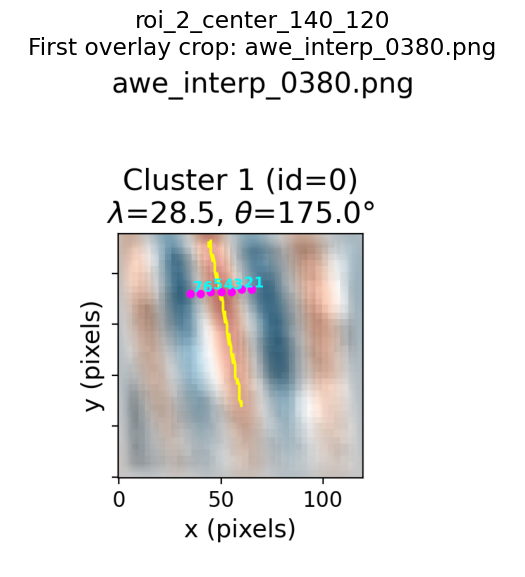

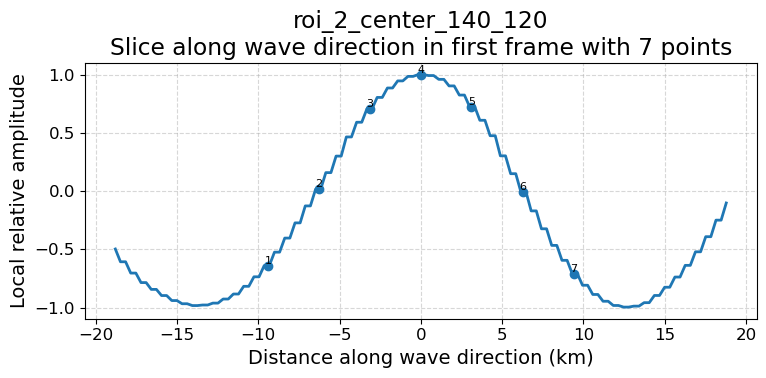

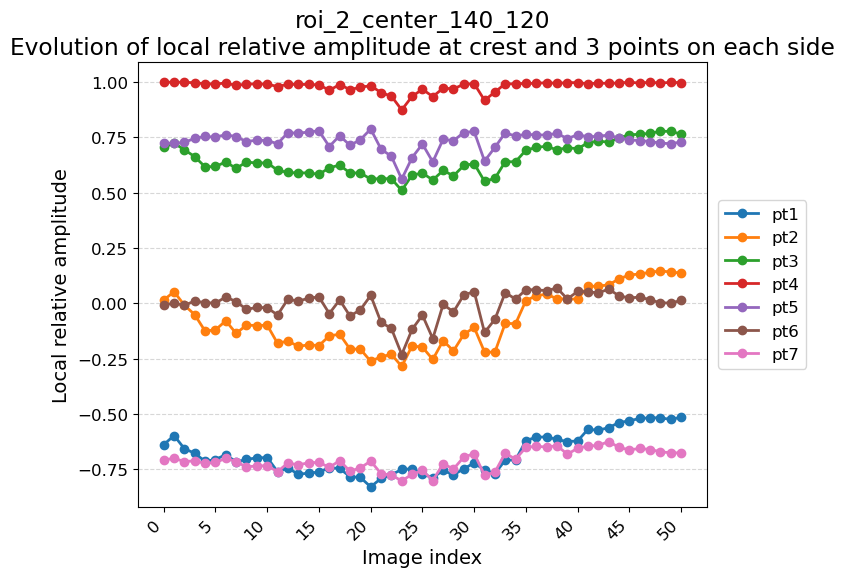

In [14]:
# %%
# Full PNG frame -> background removal -> wavelet clusters
# (batch version, with crest marker + ridge line + relative-amplitude panel)
#
# MULTI ROI VERSION:
#   - Define many ROIs in ROI_SETS
#   - Runs the same pipeline for each ROI
#   - Saves each ROI run into its own subfolder so nothing overwrites
#
# For each PNG in FRAME_DIR, this script:
#   - Removes a 2D plane + first Fourier mode as "background"
#   - Applies optional edge taper
#   - Runs juwavelet 2D CWT
#   - Applies band-pass + angle filters before clustering
#   - Identifies clusters on the filtered decomposition
#   - Reconstructs the strongest cluster
#   - Saves a figure with 3 columns:
#         LEFT:   background (remaining_tapered_clean, centered)
#         MIDDLE: background + cluster reconstruction overlay
#                  + ridge line (skeleton) along the bright band
#         RIGHT:  local relative amplitude:
#                  for each pixel, neighborhood radius λ/2 (km),
#                  local max -> +1, local min -> -1, clipped to [-1, 1].
#
# Additionally, per ROI:
#   - Uses ONLY the first crest from the FIRST frame (cluster 0)
#   - From that crest, defines 7 points along the wave direction
#     in BOTH directions, including the crest:
#         offsets = [-3, -2, -1, 0, +1, +2, +3] steps
#   - For each frame, samples local relative amplitude at those 7 pixels
#   - Saves amplitude evolution to:
#         crest_relative_amplitude_evolution.npy
#         crest_relative_amplitude_evolution.csv
#   - CSV now ALSO includes, per saved frame:
#         dominant_wavelength_km, dominant_theta_deg
#     (from the dominant cluster’s (s,t) location)
#   - Plots relative amplitude vs image index for the 7 points.
#   - After the first overlay image, also shows a 1D slice along the
#     wave direction in the first frame, with the 7 points marked.
%matplotlib inline

from __future__ import annotations
from typing import Tuple, Optional, List

from pathlib import Path
import csv

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio.v3 as iio

from scipy.ndimage import median_filter, maximum_filter, minimum_filter
from scipy import ndimage
from skimage import morphology

from juwavelet import transform, utils

def _silent_print(*args, **kwargs):
    pass

utils.print = _silent_print

# --------------------------
# User params
# --------------------------

# Folder with input PNG frames
FRAME_DIR = out_dir / "awe_radiance_200km_box_interpolated_frames_cropped"

# Optional explicit output folder for overlays
# If None, a subfolder "overlays_crests_phase" will be created inside FRAME_DIR
OVERLAY_DIR: Optional[str] = None

# ---- MULTIPLE ROIs ----
# Each tuple: (name, X_SLICE, Y_SLICE)
ROI_SETS = [
    ("roi_2_center_140_120", slice(80, 200), slice(60, 180)),
    #("roi_1_center_150_100", slice(90, 210), slice(40, 160)),
    #("roi_2_center_80_100", slice(20, 140), slice(40, 160)),
    # Add more as needed
]

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (DISABLED as requested)
APPLY_DESPIKE = False
DESPIKE_SIZE = 5
DESPIKE_K = 2.0

# Wavelet params
S0 = 8
DJ = 1/12
JS = 24
JT = 36
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.625
DY = 0.625

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25
CLUSTER_THR = 0.1

# Band-pass filter on effective wavelength λ (km)
ENABLE_BANDPASS = False
BANDPASS_LMIN_KM = 8.0
BANDPASS_LMAX_KM = 16.0

# Angle filter on wave-vector direction (degrees)
ENABLE_ANGLE_FILTER = True
ANGLE_MIN_DEG = 120.0
ANGLE_MAX_DEG = 180.0

# Cluster plotting controls
MAX_CLUSTERS = 1

# Crest detection parameters (only 1 crest)
CREST_NEIGHBORHOOD = 7
CREST_MIN_RELAMP = 0.2
CRESTS_PER_CLUSTER = 1

# Tracking params
N_SAMPLE_POINTS = 7

# Plot controls
SHOW_FIGS = False
SAVE_OVERLAY = True

# Verbosity
VERBOSE = False

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": [12, 8],
})

# --------------------------
# Small logger
# --------------------------
def log(msg: str) -> None:
    if VERBOSE:
        print(msg)

# --------------------------
# Helpers
# --------------------------
def load_image(path: str) -> np.ndarray:
    """
    Load single-frame 2D image (PNG / TIFF) as float32 array.
    Using imageio (iio.imread) so PNGs work fine.
    """
    img = iio.imread(path)

    # If RGB/RGBA, convert to grayscale by simple average
    if img.ndim == 3:
        img = np.mean(img, axis=-1)

    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D image; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:
      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0
    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.
    Kept for completeness but disabled via APPLY_DESPIKE=False.
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D taper only near the edges.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)
    return Z * W


# --------------------------
# Helpers for λ and angle
# --------------------------
def compute_lambda_theta_fields(cwt: dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute effective wavelength λ (km) and angle θ (deg) for all (s, t).

    λ from λx, λy via: 1/λ² = 1/λx² + 1/λy²
    θ from kx, ky via atan2(ky, kx), wrapped to [0, 180).
    """
    lamx = np.asarray(cwt["wavelength_x"], float)
    lamy = np.asarray(cwt["wavelength_y"], float)

    with np.errstate(divide="ignore", invalid="ignore"):
        inv_lamx2 = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / (lamx**2), 0.0)
        inv_lamy2 = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / (lamy**2), 0.0)
        inv2 = inv_lamx2 + inv_lamy2
        lam_eff = np.where(inv2 > 0, 1.0 / np.sqrt(inv2), np.inf)

        kx = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx, 0.0)
        ky = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy, 0.0)

        theta_deg = np.degrees(np.arctan2(ky, kx))
        theta_deg = np.mod(theta_deg, 180.0)

    return lam_eff, theta_deg


def compute_cluster_lambda_and_angle(
    cwt: dict,
    idx_s: int,
    idx_t: int,
) -> Tuple[float, float]:
    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)
    lam = float(lam_eff[idx_s, idx_t])
    theta = float(theta_deg[idx_s, idx_t])
    return lam, theta


# --------------------------
# Crest detection (only 1 crest)
# --------------------------
def find_top_crests(
    Z: np.ndarray,
    num: int = 1,
    neighborhood: int = 7,
    min_rel_amp: float = 0.2,
) -> List[Tuple[int, int, float]]:
    """
    Find up to `num` strongest local crests (positive local maxima) in Z.
    Returns list of (iy, ix, value) sorted by descending value.
    """
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return []

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        return []

    neighborhood = max(int(neighborhood), 1)
    local_max = maximum_filter(Z, size=neighborhood, mode="nearest")
    mask = (Z == local_max) & (Z > 0) & (Z >= min_rel_amp * max_val)

    ys, xs = np.where(mask)
    if ys.size == 0:
        iy, ix = np.unravel_index(np.nanargmax(Z), Z.shape)
        return [(int(iy), int(ix), float(Z[iy, ix]))][:num]

    vals = Z[ys, xs]
    order = np.argsort(vals)[::-1]

    crests: List[Tuple[int, int, float]] = []
    for idx in order[:num]:
        crests.append((int(ys[idx]), int(xs[idx]), float(vals[idx])))

    return crests


# --------------------------
# Ridge line (skeleton) along the bright band
# --------------------------
def compute_ridge_mask(Z: np.ndarray, level_frac: float = 0.6) -> np.ndarray:
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return np.zeros_like(Z, dtype=bool)

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        return np.zeros_like(Z, dtype=bool)

    level = level_frac * max_val
    mask = Z >= level
    if not np.any(mask):
        return np.zeros_like(Z, dtype=bool)

    labels, num = ndimage.label(mask)
    if num == 0:
        return np.zeros_like(Z, dtype=bool)

    iy_max, ix_max = np.unravel_index(np.nanargmax(Z), Z.shape)
    label_peak = labels[iy_max, ix_max]
    if label_peak == 0:
        return np.zeros_like(Z, dtype=bool)

    peak_comp = labels == label_peak
    ridge = morphology.skeletonize(peak_comp)
    return ridge


# --------------------------
# Single-file pipeline
# --------------------------
def run_pipeline_for_file(
    img_path: Path,
    overlay_dir: Path,
    x_slice: Optional[slice],
    y_slice: Optional[slice],
    show_figs: bool = False,
    save_overlay: bool = True,
    crest_iy: Optional[np.ndarray] = None,  # sample_iy (7 points)
    crest_ix: Optional[np.ndarray] = None,  # sample_ix (7 points)
    init_crests_from_this_file: bool = False,
) -> Tuple[
    Optional[np.ndarray],  # vals_on_crests (7,)
    Optional[np.ndarray],  # crest_iy
    Optional[np.ndarray],  # crest_ix
    Optional[dict],        # first_frame_info
    Optional[float],       # dom_lambda_km
    Optional[float],       # dom_theta_deg
]:
    """
    Run the pipeline on one frame for one ROI.

    Returns:
      vals_on_crests: 1D array (7,)
      crest_iy, crest_ix: stored sample indices
      first_frame_info: dict for slice plot
      dom_lambda_km, dom_theta_deg: dominant cluster wavelength/orientation (per frame)
    """
    log(f"\n=== Processing {img_path.name} ===")
    full = load_image(str(img_path))
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    first_frame_info: Optional[dict] = None

    # Optional preview of full frame + ROI rectangle
    if show_figs:
        vals_full = full.ravel().astype(float)
        p2, p98 = np.nanpercentile(vals_full, [2, 98])
        vmin_prev, vmax_prev = p2, p98
        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()
        im_prev = ax_prev.pcolormesh(
            x_full, y_full_flip, full,
            shading="auto", cmap="gray",
            vmin=vmin_prev, vmax=vmax_prev,
        )
        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")
        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{img_path.name}\nFull frame (2 to 98 percentile stretch)")
        ax_prev.set_aspect("equal", adjustable="box")

        ysl_full = y_slice if y_slice is not None else slice(0, ny_full)
        xsl_full = x_slice if x_slice is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    # ROI slice (full if None)
    ysl = y_slice if y_slice is not None else slice(None, None)
    xsl = x_slice if x_slice is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]

    log(f"[ROI] shape: {raw.shape}")

    proc0 = raw.copy()

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike (disabled)
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # Optional background figure
    if show_figs:
        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original (median-sub)"),
            (bg_c, "Background (plane + first Fourier)"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining with edge taper"),
        ]

        im_bg = None
        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(
                x1d, y1d, Z,
                shading="auto", cmap="RdBu_r",
                vmin=vmin, vmax=vmax,
            )
            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                                  fraction=0.04, pad=0.02)
        cbar_bg.set_label("Intensity (a.u.)")
        plt.show()

    # Preprocess for CWT (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Apply band-pass and angle filters before clustering
    decomposition = cwt["decomposition"]
    ns, nt, nx_cwt, ny_cwt = decomposition.shape

    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)
    mask_keep = np.ones_like(lam_eff, dtype=bool)

    if ENABLE_BANDPASS:
        mask_keep &= (
            np.isfinite(lam_eff)
            & (lam_eff >= BANDPASS_LMIN_KM)
            & (lam_eff <= BANDPASS_LMAX_KM)
        )

    if ENABLE_ANGLE_FILTER:
        mask_keep &= (
            np.isfinite(theta_deg)
            & (theta_deg >= ANGLE_MIN_DEG)
            & (theta_deg <= ANGLE_MAX_DEG)
        )

    mask4 = mask_keep[:, :, None, None].astype(decomposition.dtype)
    decomposition *= mask4

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    orig_decomp = decomposition.copy()

    # Background for overlays
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    n_clusters = len(amps) if amps is not None else 0
    log(f"[Clusters] n_clusters (after filters) = {n_clusters}")

    crest_iy_out = crest_iy
    crest_ix_out = crest_ix
    vals_on_crests: Optional[np.ndarray] = None

    # NEW: dominant cluster (wavelength/orientation) for this frame
    dom_lambda_km: Optional[float] = None
    dom_theta_deg: Optional[float] = None

    if n_clusters == 0:
        fig_empty, ax = plt.subplots(figsize=(6, 4))
        ax.pcolormesh(
            x1d, y1d, bg_tapered_centered,
            shading="auto", cmap="gray",
            vmin=bg_vmin, vmax=bg_vmax,
        )
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_title("No clusters after filters")
        fig_empty.tight_layout()

        if save_overlay:
            overlay_dir.mkdir(parents=True, exist_ok=True)
            out_path = overlay_dir / f"{img_path.stem}_overlay_clusters_crests_phase.png"
            fig_empty.savefig(out_path, dpi=200)

        if show_figs:
            plt.show(fig_empty)
        else:
            plt.close(fig_empty)

        return None, crest_iy_out, crest_ix_out, None, None, None

    # Sort clusters by amplitude and limit to MAX_CLUSTERS
    order = np.argsort(amps)[::-1]
    n_show = min(n_clusters, MAX_CLUSTERS)

    fig, axes = plt.subplots(
        n_show, 3,
        figsize=(15, 4 * n_show),
        sharex=True, sharey=True,
    )
    axes = np.atleast_2d(axes)

    for j in range(n_show):
        kcl = int(order[j])
        ax_bg = axes[j, 0]
        ax_ov = axes[j, 1]
        ax_ph = axes[j, 2]

        # LEFT: background
        ax_bg.pcolormesh(
            x1d, y1d, bg_tapered_centered,
            shading="auto", cmap="gray",
            vmin=bg_vmin, vmax=bg_vmax,
        )
        ax_bg.set_title("Background (remaining_tapered_clean)")
        ax_bg.set_aspect("equal", adjustable="box")
        ax_bg.set_xlabel("x (pixels)")
        ax_bg.set_ylabel("y (pixels)")

        # MIDDLE: overlay (background + reconstruction)
        decomposition[:] = orig_decomp
        decomposition[iwave != kcl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)
        rec_centered = rec.T - np.median(rec)  # (ny, nx)
        ny_img, nx_img = rec_centered.shape

        ax_ov.pcolormesh(
            x1d, y1d, bg_tapered_centered,
            shading="auto", cmap="gray",
            vmin=bg_vmin, vmax=bg_vmax,
        )

        cl_vmin, cl_vmax = -0.6, 0.6
        ax_ov.pcolormesh(
            x1d, y1d, rec_centered,
            shading="auto", cmap="RdBu_r",
            vmin=cl_vmin, vmax=cl_vmax,
            alpha=0.6,
        )

        # Ridge line
        ridge_mask = compute_ridge_mask(rec_centered, level_frac=0.6)
        if np.any(ridge_mask):
            ys_ridge, xs_ridge = np.where(ridge_mask)
            order_r = np.argsort(xs_ridge)
            xs_sorted = xs_ridge[order_r].astype(float)
            ys_sorted = ys_ridge[order_r].astype(float)
            x_disp_r = xs_sorted
            y_disp_r = ny_img - 1 - ys_sorted
            ax_ov.plot(x_disp_r, y_disp_r, linewidth=1.5, color="yellow")

        # Wavelength and angle (from cluster (s,t))
        s_idx = int(idxs[kcl][0])
        t_idx = int(idxs[kcl][1])
        lam_best, theta_best = compute_cluster_lambda_and_angle(cwt, s_idx, t_idx)

        # NEW: store dominant cluster wavelength/orientation for this frame
        if j == 0:
            dom_lambda_km = float(lam_best)
            dom_theta_deg = float(theta_best)

        title_str = (
            f"Cluster {j+1} (id={kcl})\n"
            rf"$\lambda$={_fmt(lam_best)}, $\theta$={theta_best:.1f}°"
        )
        ax_ov.set_title(title_str)
        ax_ov.set_aspect("equal", adjustable="box")
        ax_ov.set_xlabel("x (pixels)")
        ax_ov.set_ylabel("y (pixels)")

        # RIGHT: local relative amplitude
        if np.isfinite(lam_best) and lam_best > 0:
            radius_km = lam_best / 2.0
            radius_pix = max(int(np.round(radius_km / DX)), 1)
        else:
            radius_pix = 1

        win_size = 2 * radius_pix + 1
        local_max = maximum_filter(rec_centered, size=win_size, mode="nearest")
        local_min = minimum_filter(rec_centered, size=win_size, mode="nearest")
        denom = local_max - local_min
        denom_safe = np.where(denom != 0, denom, np.nan)

        rel_amp = -1.0 + 2.0 * (rec_centered - local_min) / denom_safe
        rel_amp = np.where(np.isfinite(rel_amp), rel_amp, 0.0)
        rel_amp = np.clip(rel_amp, -1.0, 1.0)

        mask_cluster_xy = np.any(iwave == kcl, axis=(0, 1))   # (nx, ny)
        mask_cluster_img = mask_cluster_xy.T                  # (ny, nx)
        rel_amp_cluster = np.where(mask_cluster_img, rel_amp, np.nan)

        im_rel = ax_ph.pcolormesh(
            x1d, y1d, rel_amp_cluster,
            shading="auto", cmap="RdBu_r",
            vmin=-1.0, vmax=1.0,
        )
        ax_ph.set_title(r"Local relative amplitude (radius $\lambda/2$)")
        ax_ph.set_aspect("equal", adjustable="box")
        ax_ph.set_xlabel("x (pixels)")
        ax_ph.set_ylabel("y (pixels)")

        cbar_ph = fig.colorbar(im_rel, ax=ax_ph, fraction=0.046, pad=0.04)
        cbar_ph.set_label("Relative amplitude")

        # Find ONLY 1 crest
        crests = find_top_crests(
            rec_centered,
            num=CRESTS_PER_CLUSTER,
            neighborhood=CREST_NEIGHBORHOOD,
            min_rel_amp=CREST_MIN_RELAMP,
        )

        # Crest tracking (first cluster only)
        if j == 0:
            if init_crests_from_this_file and crest_iy_out is None and crest_ix_out is None:
                if len(crests) > 0:
                    crest0_iy, crest0_ix, _ = crests[0]

                    theta_rad = np.deg2rad(theta_best)
                    ux = np.cos(theta_rad)
                    uy = np.sin(theta_rad)

                    step_pix = max(radius_pix // 4, 1)

                    offsets = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)
                    if offsets.size != N_SAMPLE_POINTS:
                        offsets = np.linspace(-3, 3, N_SAMPLE_POINTS)

                    sample_ix = crest0_ix + np.round(step_pix * offsets * ux).astype(int)
                    sample_iy = crest0_iy + np.round(step_pix * offsets * uy).astype(int)

                    pixel_shifts = np.array([0, 0, 0, 0, 0, 0, 0], dtype=float)
                    for idx, pix_shift in enumerate(pixel_shifts):
                        dxp = int(np.round(pix_shift * ux))
                        dyp = int(np.round(pix_shift * uy))
                        sample_ix[idx] += dxp
                        sample_iy[idx] += dyp

                    sample_ix = np.clip(sample_ix, 0, nx_img - 1)
                    sample_iy = np.clip(sample_iy, 0, ny_img - 1)

                    crest_ix_out = sample_ix
                    crest_iy_out = sample_iy

                    # Mark sample points
                    for n in range(N_SAMPLE_POINTS):
                        x_disp = float(crest_ix_out[n])
                        y_disp = float(ny_img - 1 - crest_iy_out[n])
                        ax_ov.plot(
                            x_disp, y_disp,
                            marker="o",
                            markersize=4,
                            markeredgecolor="magenta",
                            markerfacecolor="magenta",
                            markeredgewidth=0.8,
                        )
                        ax_ov.text(
                            x_disp + 1.0, y_disp + 1.0,
                            f"{n+1}",
                            color="cyan",
                            fontsize=8,
                            weight="bold",
                        )

            if init_crests_from_this_file and crest_iy_out is not None and crest_ix_out is not None:
                first_frame_info = {
                    "rel_amp": rel_amp.copy(),
                    "crest_iy": crest_iy_out.copy(),
                    "crest_ix": crest_ix_out.copy(),
                }

            if crest_iy_out is not None and crest_ix_out is not None:
                if (crest_iy_out.max() < ny_img) and (crest_ix_out.max() < nx_img):
                    vals_on_crests = rel_amp[crest_iy_out, crest_ix_out]
                else:
                    vals_on_crests = None

    fig.suptitle(f"{img_path.name}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{img_path.stem}_overlay_clusters_crests_phase.png"
        fig.savefig(out_path, dpi=200)

    if show_figs:
        plt.show(fig)
    else:
        plt.close(fig)

    return vals_on_crests, crest_iy_out, crest_ix_out, first_frame_info, dom_lambda_km, dom_theta_deg


# --------------------------
# Batch driver (per ROI)
# --------------------------
def run_batch_one_roi(roi_name: str, x_slice: slice, y_slice: slice) -> None:
    frame_dir = Path(FRAME_DIR)

    if OVERLAY_DIR is not None:
        base_overlay_dir = Path(OVERLAY_DIR)
    else:
        base_overlay_dir = frame_dir / "overlays_crests_phase"

    overlay_dir = base_overlay_dir / roi_name

    files = sorted(list(frame_dir.glob("*.png")))
    if not files:
        print(f"No PNG image files found in {frame_dir}")
        return

    print(f"\nROI: {roi_name}")
    print(f"  X_SLICE: {x_slice}")
    print(f"  Y_SLICE: {y_slice}")
    print(f"  Found {len(files)} PNG image files in {frame_dir}")
    print(f"  Overlay output directory: {overlay_dir}")

    crest_iy = None
    crest_ix = None
    crest_value_series: List[np.ndarray] = []
    frame_indices: List[int] = []

    # NEW: dominant wavelength/orientation series (aligned with frames we save)
    dom_lambda_series: List[float] = []
    dom_theta_series: List[float] = []

    first_frame_info: Optional[dict] = None

    for i, img_path in enumerate(files):
        vals_on_crests, crest_iy, crest_ix, first_info, dom_lam_km, dom_theta_deg = run_pipeline_for_file(
            img_path=img_path,
            overlay_dir=overlay_dir,
            x_slice=x_slice,
            y_slice=y_slice,
            show_figs=SHOW_FIGS,
            save_overlay=SAVE_OVERLAY,
            crest_iy=crest_iy,
            crest_ix=crest_ix,
            init_crests_from_this_file=(i == 0),
        )

        if first_frame_info is None and first_info is not None:
            first_frame_info = first_info

        if vals_on_crests is not None:
            crest_value_series.append(vals_on_crests)
            frame_indices.append(i)

            dom_lambda_series.append(float(dom_lam_km) if dom_lam_km is not None else np.nan)
            dom_theta_series.append(float(dom_theta_deg) if dom_theta_deg is not None else np.nan)

    # Save and plot evolution
    if not crest_value_series:
        print("  No amplitude data collected for this ROI.")
        return

    val_arr = np.vstack(crest_value_series)
    n_files_used, n_points = val_arr.shape
    frames = np.array(frame_indices, dtype=int)

    overlay_dir.mkdir(parents=True, exist_ok=True)

    # NPY
    npy_path = overlay_dir / "crest_relative_amplitude_evolution.npy"
    np.save(npy_path, val_arr)

    # CSV (now includes dominant_wavelength_km and dominant_theta_deg)
    csv_path = overlay_dir / "crest_relative_amplitude_evolution.csv"
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        header = ["image_index", "dominant_wavelength_km", "dominant_theta_deg"] + [f"pt{p+1}" for p in range(n_points)]
        writer.writerow(header)

        for irow in range(n_files_used):
            row = [
                int(frames[irow]),
                float(dom_lambda_series[irow]),
                float(dom_theta_series[irow]),
            ] + [float(x) for x in val_arr[irow, :]]
            writer.writerow(row)

    print(f"  Saved: {npy_path}")
    print(f"  Saved: {csv_path}")

    # Show first overlay crop
    try:
        first_overlay_path = overlay_dir / f"{files[0].stem}_overlay_clusters_crests_phase.png"
        if first_overlay_path.exists():
            img0 = plt.imread(first_overlay_path)
            h, w = img0.shape[:2]

            x0c, x1c = 1100, 1900
            x0c = max(0, min(x0c, w - 1))
            x1c = max(x0c + 1, min(x1c, w))
            img0_crop = img0[:, x0c:x1c, :]

            fig0, ax0 = plt.subplots(figsize=(6, 6))
            ax0.imshow(img0_crop)
            ax0.set_axis_off()
            ax0.set_title(f"{roi_name}\nFirst overlay crop: {files[0].name}")
            plt.tight_layout()
            plt.show()
    except Exception as e:
        if VERBOSE:
            print(f"[Warning] Could not display first overlay image: {e}")

    # Slice along wave direction in first frame
    if first_frame_info is not None:
        rel0 = np.asarray(first_frame_info["rel_amp"], float)
        samp_iy = np.asarray(first_frame_info["crest_iy"], float)
        samp_ix = np.asarray(first_frame_info["crest_ix"], float)
        ny0, nx0 = rel0.shape

        x0_mean = samp_ix.mean()
        y0_mean = samp_iy.mean()

        vx = samp_ix[-1] - samp_ix[0]
        vy = samp_iy[-1] - samp_iy[0]
        norm = np.hypot(vx, vy)
        if norm == 0:
            vx, vy, norm = 1.0, 0.0, 1.0
        ux = vx / norm
        uy = vy / norm

        s_pts = (samp_ix - x0_mean) * ux + (samp_iy - y0_mean) * uy
        center_idx = N_SAMPLE_POINTS // 2
        s0 = s_pts[center_idx] if 0 <= center_idx < len(s_pts) else s_pts.mean()

        dist_pts_km = (s_pts - s0) * DX

        margin_pix = norm * 0.5
        s_min = s_pts.min() - margin_pix
        s_max = s_pts.max() + margin_pix
        n_line = max(int((s_max - s_min) * 2), 50)
        s_line = np.linspace(s_min, s_max, n_line)

        x_line = x0_mean + s_line * ux
        y_line = y0_mean + s_line * uy

        x_idx = np.clip(np.round(x_line).astype(int), 0, nx0 - 1)
        y_idx = np.clip(np.round(y_line).astype(int), 0, ny0 - 1)

        rel_slice = rel0[y_idx, x_idx]
        dist_line_km = (s_line - s0) * DX
        pt_vals0 = val_arr[0, :]

        fig_slice, ax_slice = plt.subplots(figsize=(8, 4))
        ax_slice.plot(dist_line_km, rel_slice, linewidth=2)
        ax_slice.scatter(dist_pts_km, pt_vals0, zorder=3)
        for n in range(len(dist_pts_km)):
            ax_slice.text(
                dist_pts_km[n], pt_vals0[n],
                f"{n+1}",
                fontsize=8,
                ha="center",
                va="bottom",
            )
        ax_slice.set_xlabel("Distance along wave direction (km)")
        ax_slice.set_ylabel("Local relative amplitude")
        ax_slice.set_title(f"{roi_name}\nSlice along wave direction in first frame with 7 points")
        ax_slice.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    # Evolution plot
    fig, ax = plt.subplots(figsize=(10, 6))
    for p in range(n_points):
        ax.plot(frames, val_arr[:, p], marker="o", linewidth=2, label=f"pt{p+1}")

    ax.set_xlabel("Image index")
    ax.set_ylabel("Local relative amplitude")
    ax.set_title(f"{roi_name}\nEvolution of local relative amplitude at crest and 3 points on each side")

    if len(frames) > 0:
        tick_positions = frames[::5]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_positions, rotation=45, ha="right")
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])

    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def run_all_rois() -> None:
    if not ROI_SETS:
        print("ROI_SETS is empty. Add at least one ROI.")
        return

    for roi_name, xsl, ysl in ROI_SETS:
        run_batch_one_roi(roi_name, xsl, ysl)


if __name__ == "__main__":
    run_all_rois()


## Animation from png files

In [15]:
# %%
# Make a movie (mp4 or gif) from the saved PNG overlays created by the batch cell.
#
# Looks in:
#   FRAME_DIR/overlays_crests_phase/<roi_name>/*_overlay_clusters_crests_phase.png
#
# Writes:
#   FRAME_DIR/overlays_crests_phase/<roi_name>/<roi_name>_overlay_clusters_crests_phase.mp4
#
# Requirements:
#   pip install imageio imageio-ffmpeg
# or
#   conda install -c conda-forge ffmpeg imageio imageio-ffmpeg

from __future__ import annotations
from pathlib import Path
import re

import imageio.v2 as imageio


# --------------------------
# Settings
# --------------------------
FPS = 5

# If None, uses Path(FRAME_DIR)/"overlays_crests_phase" (same default as your batch)
OVERLAY_BASE_DIR: str | None = None

# If you only want some ROIs, set e.g. ["center_200_200"]; otherwise leave None
ONLY_ROIS: list[str] | None = None

PNG_GLOB = "*_overlay_clusters_crests_phase.png"

# "mp4" recommended; "gif" also supported
OUT_EXT = "mp4"   # "mp4" or "gif"


# --------------------------
# Helpers
# --------------------------
def _natural_key(p: Path):
    # Sort by the last integer in the filename (often the frame index), fallback to name
    nums = re.findall(r"\d+", p.stem)
    n = int(nums[-1]) if nums else -1
    return (n, p.name)


def make_movie_from_pngs(pngs: list[Path], out_path: Path, fps: int) -> None:
    if not pngs:
        raise ValueError("No PNGs provided.")

    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.suffix.lower() == ".gif":
        with imageio.get_writer(out_path, mode="I", duration=1.0 / fps) as writer:
            for p in pngs:
                writer.append_data(imageio.imread(p))
        return

    # mp4
    try:
        with imageio.get_writer(out_path, fps=fps, codec="libx264", quality=8) as writer:
            for p in pngs:
                writer.append_data(imageio.imread(p))
    except Exception as e:
        raise RuntimeError(
            "Failed to write MP4. You probably need ffmpeg.\n"
            "Try one of these:\n"
            "  conda install -c conda-forge ffmpeg imageio-ffmpeg\n"
            "  pip install imageio-ffmpeg\n"
            f"Original error: {e}"
        )


# --------------------------
# Main
# --------------------------
frame_dir = Path(FRAME_DIR)

overlay_base = Path(OVERLAY_BASE_DIR) if OVERLAY_BASE_DIR is not None else (frame_dir / "overlays_crests_phase")

roi_names = [r[0] for r in ROI_SETS]
if ONLY_ROIS is not None:
    only = set(ONLY_ROIS)
    roi_names = [r for r in roi_names if r in only]

if not roi_names:
    raise ValueError("No ROI names found. Check ROI_SETS / ONLY_ROIS.")

print("Overlay base:", overlay_base)
print("ROIs:", roi_names)
print("FPS:", FPS, "| Output:", OUT_EXT)

for roi in roi_names:
    roi_dir = overlay_base / roi
    if not roi_dir.exists():
        print(f"[skip] ROI folder not found: {roi_dir}")
        continue

    pngs = sorted(roi_dir.glob(PNG_GLOB), key=_natural_key)
    if not pngs:
        print(f"[skip] No PNGs in: {roi_dir} (pattern: {PNG_GLOB})")
        continue

    out_path = roi_dir / f"{roi}_overlay_clusters_crests_phase.{OUT_EXT}"
    print(f"[write] {roi}: {len(pngs)} frames -> {out_path.name}")

    make_movie_from_pngs(pngs, out_path, fps=FPS)

print("Done.")


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 800) to (3008, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Overlay base: 10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped/overlays_crests_phase
ROIs: ['roi_2_center_140_120']
FPS: 5 | Output: mp4
[write] roi_2_center_140_120: 51 frames -> roi_2_center_140_120_overlay_clusters_crests_phase.mp4
Done.


## Grid Search

* Automatically finds `crest_relative_amplitude_evolution.csv` using `FRAME_DIR` / `OVERLAY_DIR`
* Does a grid search over **a** (around your original (18$^\circ$ / 50))
* For each trial `a`, and for each point, finds the best **b** (phase) assuming `y ≈ cos(a t + b)` with *unit amplitude and no offset*
* Picks the `a` that gives the smallest total SSE
* Recomputes the best **b** for that `a`
* Plots:

  * SSE vs `a`
  * Data + fitted `cos(a t + b)` curves


Overlay base directory: 10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped/overlays_crests_phase
DT between frames = 1.100 s
Initial a0 ≈ 0.333333 deg per frame

----------------------------------------
ROI: roi_2_center_140_120
Loading CSV from: 10308_1la_v23_86/awe_radiance_200km_box_interpolated_frames_cropped/overlays_crests_phase/roi_2_center_140_120/crest_relative_amplitude_evolution.csv
Data shape (frames, points): (51, 7)
Average dominant wavelength from CSV: 29.7386 km

Best a from grid search:
  a_best ≈ 0.164583 deg per frame (initial 0.333333, factor 0.494)
  SSE_min = 1.5698

Per-point best phases b (rad):
  pt1: b ≈ 3.892 rad (223.0 deg), SSE=0.2967
  pt2: b ≈ 4.564 rad (261.5 deg), SSE=0.6351
  pt3: b ≈ 5.349 rad (306.5 deg), SSE=0.1877
  pt4: b ≈ 6.030 rad (345.5 deg), SSE=0.0335
  pt5: b ≈ 5.472 rad (313.5 deg), SSE=0.1253
  pt6: b ≈ 4.634 rad (265.5 deg), SSE=0.2195
  pt7: b ≈ 3.848 rad (220.5 deg), SSE=0.0720

Phase speed (using average dominant wave

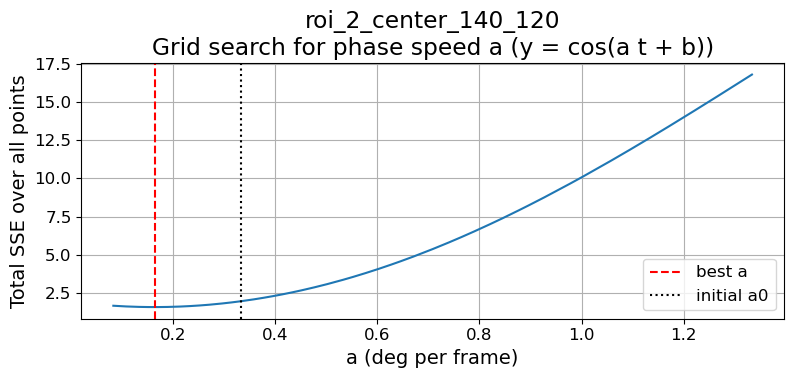

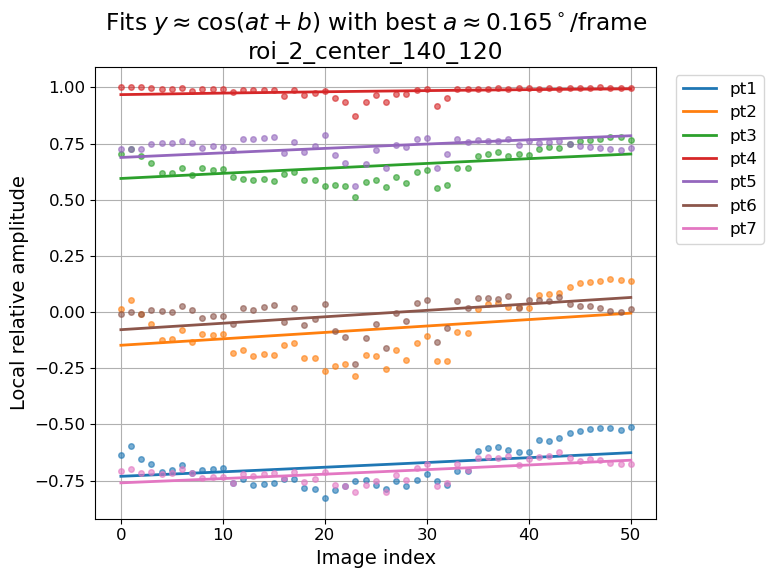

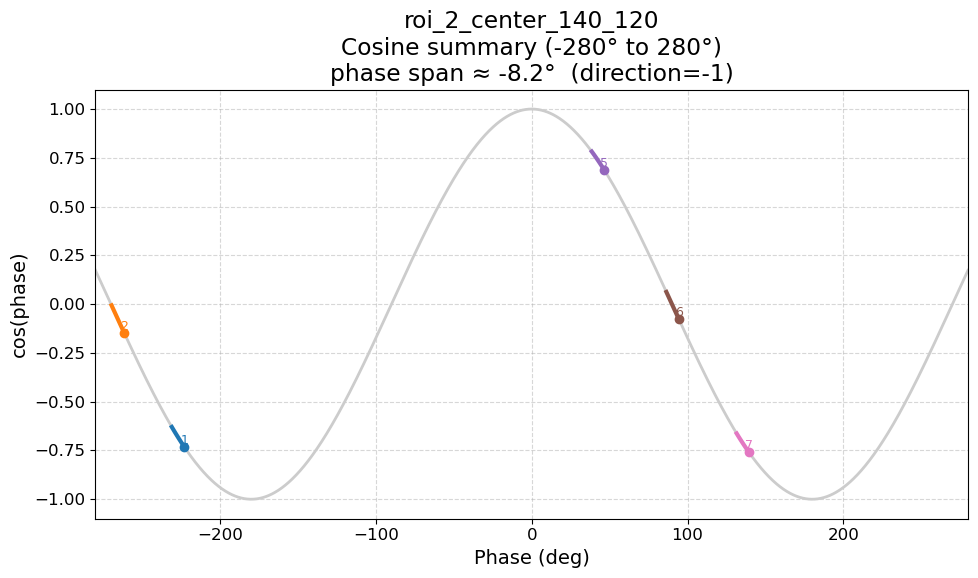


================ SUMMARY ================ 
roi_2_center_140_120:  a=0.1646 deg/frame, period(360)=2406.1 s, λ_avg=29.74 km, c=12.36 m/s, SSE=1.570


In [17]:
# %%
from __future__ import annotations

from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Multi-ROI grid search for y ≈ cos(a t + b)
# + compute horizontal phase speed using DOMINANT wavelength from CSV
#
# New CSV format (per saved frame):
#   image_index, dominant_wavelength_km, dominant_theta_deg, pt1, pt2, ..., ptN
#
# This script:
# - Reads the new CSV
# - Uses Y = pt columns only
# - Uses lambda_km = average(dominant_wavelength_km) across saved frames
#   (ignores NaNs)
#
# Phase speed:
#   best_a_deg is deg/frame
#   deg/s = best_a_deg / DT_FRAME_S
#   period_s = 360 / (deg/s) = 360 * DT_FRAME_S / best_a_deg
#   c = (lambda_km*1000) / period_s
# ============================================================

# -----------------------------
# User settings
# -----------------------------

# Folder with input PNG frames
FRAME_DIR = out_dir / "awe_radiance_200km_box_interpolated_frames_cropped"

# Optional explicit output folder for overlays
# If None, a subfolder "overlays_crests_phase" will be created inside FRAME_DIR
OVERLAY_DIR: Optional[str] = None

DT_FRAME_S = 1.1  # seconds between frames (your value)

# Grid search setup
a0_deg = 20 / 60           # deg per frame
f_min, f_max = 0.25, 4
n_trial = 201
n_b = 720

# Plot controls
MAKE_SSE_PLOT = True
MAKE_DATA_FIT_PLOT = True
MAKE_COS_SUMMARY_PLOT = True

# Cos summary controls
COS_DOMAIN_DEG = (-280, 280)
SHIFT_FIRST_THREE_BY_360 = True
direction = -1  # +1 original direction, -1 opposite propagation

# -----------------------------
# Helper: overlay dir
# -----------------------------
def get_overlay_base_dir() -> Path:
    frame_dir = Path(FRAME_DIR)
    if OVERLAY_DIR is not None:
        return Path(OVERLAY_DIR)
    return frame_dir / "overlays_crests_phase"


# -----------------------------
# Helper: load ROI CSV (NEW FORMAT)
# -----------------------------
def load_roi_csv(roi_name: str):
    """
    New CSV columns:
      image_index, dominant_wavelength_km, dominant_theta_deg, pt1..ptN
    Returns:
      roi_dir, t, Y, dom_lambda_km, dom_theta_deg
    """
    overlay_base = get_overlay_base_dir()
    roi_dir = overlay_base / roi_name
    csv_path = roi_dir / "crest_relative_amplitude_evolution.csv"
    print("\n----------------------------------------")
    print("ROI:", roi_name)
    print("Loading CSV from:", csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(
            f"CSV not found at {csv_path}. Run the batch script for this ROI first."
        )

    data = np.genfromtxt(csv_path, delimiter=",", skip_header=1)

    if data.ndim == 1:
        data = data[None, :]  # single-row case

    if data.shape[1] < 4:
        raise ValueError(
            f"CSV at {csv_path} does not look like the new format. "
            f"Expected >= 4 columns; got {data.shape[1]}."
        )

    t = data[:, 0]                 # image indices
    dom_lambda_km = data[:, 1]      # dominant_wavelength_km
    dom_theta_deg = data[:, 2]      # dominant_theta_deg
    Y = data[:, 3:]                # pt1..ptN

    return roi_dir, t, Y, dom_lambda_km, dom_theta_deg


# -----------------------------
# Grid search: y ≈ cos(a t + b) (A=1, C0=0)
# -----------------------------
def grid_search_best_a(t, Y, a0_deg, f_min, f_max, n_trial, n_b):
    n_frames, n_pts = Y.shape

    a_trial_deg = a0_deg * np.linspace(f_min, f_max, n_trial)
    a_trial = np.deg2rad(a_trial_deg)
    b_grid = np.linspace(0.0, 2.0 * np.pi, n_b, endpoint=False)

    errors = np.zeros(n_trial)

    for k, a_k in enumerate(a_trial):
        base_phase = a_k * t
        phase_mat = base_phase[:, None] + b_grid[None, :]
        cos_mat = np.cos(phase_mat)

        sse_total = 0.0
        for j in range(n_pts):
            y = Y[:, j][:, None]
            sse_b = np.sum((y - cos_mat) ** 2, axis=0)
            sse_total += np.min(sse_b)

        errors[k] = sse_total

    best_idx = int(np.argmin(errors))
    best_a = a_trial[best_idx]
    best_a_deg = a_trial_deg[best_idx]
    return best_a, best_a_deg, a_trial_deg, errors, b_grid


# -----------------------------
# For best a: find best b per point
# -----------------------------
def best_b_per_point(t, Y, best_a, b_grid):
    n_frames, n_pts = Y.shape
    b_best = np.zeros(n_pts)
    sse_per_point = np.zeros(n_pts)

    base_phase_best = best_a * t
    phase_mat_best = base_phase_best[:, None] + b_grid[None, :]
    cos_mat_best = np.cos(phase_mat_best)

    for j in range(n_pts):
        y = Y[:, j][:, None]
        sse_b = np.sum((y - cos_mat_best) ** 2, axis=0)
        k_b = int(np.argmin(sse_b))
        b_best[j] = b_grid[k_b]
        sse_per_point[j] = sse_b[k_b]

    return b_best, sse_per_point


# -----------------------------
# Phase speed computation
# -----------------------------
def compute_phase_speed(best_a_deg, dt_frame_s, lambda_km):
    # deg per second
    phase_shift_deg_per_s = best_a_deg / dt_frame_s

    if phase_shift_deg_per_s == 0:
        return {
            "phase_shift_deg_per_frame": best_a_deg,
            "dt_frame_s": dt_frame_s,
            "period_s": np.inf,
            "lambda_km": lambda_km,
            "phase_speed_m_per_s": 0.0,
        }

    period_s = 360.0 / phase_shift_deg_per_s  # = 360*dt / best_a_deg
    lambda_m = lambda_km * 1000.0
    c_m_per_s = lambda_m / period_s

    return {
        "phase_shift_deg_per_frame": best_a_deg,
        "dt_frame_s": dt_frame_s,
        "period_s": period_s,
        "lambda_km": lambda_km,
        "phase_speed_m_per_s": c_m_per_s,
    }


# -----------------------------
# Plot utilities
# -----------------------------
def make_colors(n_pts):
    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return [base_colors[j % len(base_colors)] for j in range(n_pts)]


def plot_sse_vs_a(roi_name, a_trial_deg, errors, best_a_deg, a0_deg):
    plt.figure(figsize=(8, 4))
    plt.plot(a_trial_deg, errors, "-")
    plt.axvline(best_a_deg, color="r", linestyle="--", label="best a")
    plt.axvline(a0_deg, color="k", linestyle=":", label="initial a0")
    plt.xlabel("a (deg per frame)")
    plt.ylabel("Total SSE over all points")
    plt.title(f"{roi_name}\nGrid search for phase speed a (y = cos(a t + b))")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_data_and_fit(roi_name, t, Y, best_a, best_a_deg, b_best, colors):
    t_fine = np.linspace(t.min(), t.max(), 500)

    plt.figure(figsize=(10, 6))
    for j in range(Y.shape[1]):
        col = colors[j]
        plt.plot(t, Y[:, j], "o", ms=4, alpha=0.6, color=col)
        y_fit = np.cos(best_a * t_fine + b_best[j])
        plt.plot(t_fine, y_fit, "-", lw=2, color=col, label=f"pt{j+1}")

    plt.xlabel("Image index")
    plt.ylabel("Local relative amplitude")
    plt.title(
        r"Fits $y \approx \cos(a t + b)$ "
        rf"with best $a \approx {best_a_deg:.3f}^\circ$/frame"
        f"\n{roi_name}"
    )
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def plot_cosine_summary(
    roi_name,
    best_a_deg,
    dt_frame_s,
    lambda_km,
    b_best,
    colors,
    n_frames_for_span: int,
    direction=1,
    domain_deg=(-280, 280),
    shift_first_three_by_360=True,
):
    n_pts = len(b_best)

    phase = compute_phase_speed(best_a_deg, dt_frame_s, lambda_km)
    total_phase_span_deg = direction * phase["phase_shift_deg_per_frame"] * (n_frames_for_span - 1)

    phi_deg = np.linspace(domain_deg[0], domain_deg[1], 2000)
    cos_phi = np.cos(np.radians(phi_deg))

    start_deg = np.degrees(b_best)

    if direction < 0:
        start_deg = -start_deg

    start_deg = start_deg % 360

    if shift_first_three_by_360:
        for k in range(min(3, n_pts)):
            start_deg[k] -= 360

    if direction < 0 and n_pts >= 4:
        start_deg[3] -= 360

    end_deg = start_deg + total_phase_span_deg

    plt.figure(figsize=(10, 6))
    plt.plot(phi_deg, cos_phi, color="0.8", lw=2, label="cosine")

    for j in range(n_pts):
        c = colors[j]
        s0 = start_deg[j]
        s1 = end_deg[j]
        lo, hi = sorted((s0, s1))
        mask = (phi_deg >= lo) & (phi_deg <= hi)

        if np.any(mask):
            plt.plot(phi_deg[mask], cos_phi[mask], lw=3, color=c)

        if domain_deg[0] <= s0 <= domain_deg[1]:
            y0 = np.cos(np.radians(s0))
            plt.scatter([s0], [y0], color=c, zorder=4)
            plt.text(s0, y0, f"{j+1}", fontsize=9, ha="center", va="bottom", color=c)

    plt.xlabel("Phase (deg)")
    plt.ylabel("cos(phase)")
    plt.title(
        f"{roi_name}\nCosine summary ({domain_deg[0]}° to {domain_deg[1]}°)\n"
        f"phase span ≈ {total_phase_span_deg:.1f}°  (direction={direction})"
    )
    plt.xlim(domain_deg[0], domain_deg[1])
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ============================================================
# Main: loop over ROIs
# ============================================================

overlay_base = get_overlay_base_dir()
print("Overlay base directory:", overlay_base)
print(f"DT between frames = {DT_FRAME_S:.3f} s")
print(f"Initial a0 ≈ {a0_deg:.6f} deg per frame")

results = []

for roi_name, _, _ in ROI_SETS:
    roi_dir, t, Y, dom_lambda_km, dom_theta_deg = load_roi_csv(roi_name)

    n_frames, n_pts = Y.shape
    print("Data shape (frames, points):", Y.shape)

    # NEW: average wavelength from all saved frames (ignore NaNs)
    lambda_avg_km = float(np.nanmean(dom_lambda_km))
    if not np.isfinite(lambda_avg_km):
        raise ValueError(f"{roi_name}: average dominant_wavelength_km is NaN/inf. Check your CSV.")
    print(f"Average dominant wavelength from CSV: {lambda_avg_km:.4f} km")

    colors = make_colors(n_pts)

    best_a, best_a_deg, a_trial_deg, errors, b_grid = grid_search_best_a(
        t=t,
        Y=Y,
        a0_deg=a0_deg,
        f_min=f_min,
        f_max=f_max,
        n_trial=n_trial,
        n_b=n_b,
    )

    print("\nBest a from grid search:")
    print(f"  a_best ≈ {best_a_deg:.6f} deg per frame "
          f"(initial {a0_deg:.6f}, factor {best_a_deg/a0_deg:.3f})")
    print(f"  SSE_min = {errors[int(np.argmin(errors))]:.4f}")

    # Per-point best b
    b_best, sse_per_point = best_b_per_point(t, Y, best_a, b_grid)

    print("\nPer-point best phases b (rad):")
    for j in range(n_pts):
        print(f"  pt{j+1}: b ≈ {b_best[j]:.3f} rad ({np.degrees(b_best[j]):.1f} deg), "
              f"SSE={sse_per_point[j]:.4f}")

    # ---- Phase speed using average dominant wavelength from CSV ----
    phase = compute_phase_speed(best_a_deg, DT_FRAME_S, lambda_avg_km)

    print("\nPhase speed (using average dominant wavelength from CSV):")
    print(f"  Phase shift = {phase['phase_shift_deg_per_frame']:.4f} deg/frame")
    print(f"  DT = {phase['dt_frame_s']:.3f} s/frame")
    print(f"  Equivalent 360° period ≈ {phase['period_s']:.1f} s")
    print(f"  λ_avg = {phase['lambda_km']:.4f} km")
    print(f"  Horizontal phase speed ≈ {phase['phase_speed_m_per_s']:.2f} m/s")

    results.append({
        "roi": roi_name,
        "best_a_deg_per_frame": float(best_a_deg),
        "period_s_for_360deg": float(phase["period_s"]),
        "lambda_avg_km": float(lambda_avg_km),
        "phase_speed_m_per_s": float(phase["phase_speed_m_per_s"]),
        "sse_total": float(errors[int(np.argmin(errors))]),
    })

    if MAKE_SSE_PLOT:
        plot_sse_vs_a(roi_name, a_trial_deg, errors, best_a_deg, a0_deg)

    if MAKE_DATA_FIT_PLOT:
        plot_data_and_fit(roi_name, t, Y, best_a, best_a_deg, b_best, colors)

    if MAKE_COS_SUMMARY_PLOT:
        plot_cosine_summary(
            roi_name=roi_name,
            best_a_deg=best_a_deg,
            dt_frame_s=DT_FRAME_S,
            lambda_km=lambda_avg_km,
            b_best=b_best,
            colors=colors,
            n_frames_for_span=len(t),
            direction=direction,
            domain_deg=COS_DOMAIN_DEG,
            shift_first_three_by_360=SHIFT_FIRST_THREE_BY_360,
        )

# ---- Print a compact summary table ----
print("\n================ SUMMARY ================ ")
for r in results:
    print(
        f"{r['roi']}:  a={r['best_a_deg_per_frame']:.4f} deg/frame, "
        f"period(360)={r['period_s_for_360deg']:.1f} s, "
        f"λ_avg={r['lambda_avg_km']:.2f} km, "
        f"c={r['phase_speed_m_per_s']:.2f} m/s, "
        f"SSE={r['sse_total']:.3f}"
    )
